In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm 

In [2]:
temp = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/temp/temp*')
temp

<xarray.Dataset> Size: 348GB
Dimensions:    (time: 1205, depth: 50, latitude: 1201, longitude: 1201)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-17
Data variables:
    thetao     (time, depth, latitude, longitude) float32 348GB dask.array<chunksize=(30, 50, 1201, 1201), meta=np.ndarray>
Attributes:
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    institution:               Mercator Ocean International
    Conventions:               CF-1.8
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    credit:                    E.U. Copernicus Marine Service Information (CM...
    copernicusmarine_version:  2.2.0

In [3]:
sal = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/sal/sal*')
sal

<xarray.Dataset> Size: 348GB
Dimensions:    (time: 1205, depth: 50, latitude: 1201, longitude: 1201)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 5kB -50.0 -49.92 -49.83 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 5kB -100.0 -99.92 -99.83 ... -0.08333 0.0
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-09-17
Data variables:
    so         (time, depth, latitude, longitude) float32 348GB dask.array<chunksize=(30, 50, 1201, 1201), meta=np.ndarray>
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    institution:               Mercator Ocean International
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    Conventions:               CF-1.8
    copernicusmarine_version:  2.2.0

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('/work/bk1450/b383184/Amazon/Atlantic/notebooks/Cold_points_track_4567.csv')
df

,Unnamed: 0,lon,lat,z
0,0,-48.383747,-0.116225,8.656944
1,1,-48.384926,-0.116549,8.732905
2,2,-48.387310,-0.116325,8.799372
3,3,-48.390750,-0.115633,8.858223
4,4,-48.394245,-0.114742,8.907994
...,...,...,...,...
992,992,-49.758045,1.082278,12.039716
993,993,-49.757977,1.082384,12.040589
994,994,-49.757908,1.082478,12.041371
995,995,-49.757862,1.082562,12.042075


In [6]:
df['z'].mean()

np.float64(10.61882930892678)

Text(0.5, 1.0, 'Temperature')

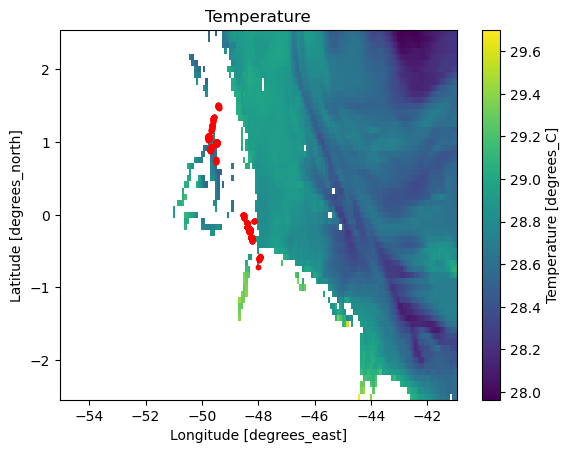

In [7]:
temp.isel(time=0,depth=8).sel(longitude=slice(-55,-41),latitude=slice(-2.5,2.5)).thetao.plot()
plt.plot(df["lon"],df["lat"],'r.')
plt.title('Temperature')

Text(0.5, 1.0, 'Sal')

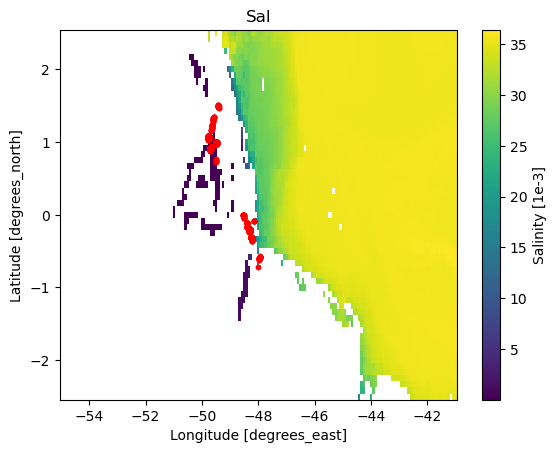

In [8]:
sal.isel(time=0,depth=8).sel(longitude=slice(-55,-41),latitude=slice(-2.5,2.5)).so.plot()
plt.plot(df["lon"],df["lat"],'r.')
plt.title('Sal')